# PBMF — single-model training (step 3)

Implements the differentiable log-rank loss and trains a single neural biomarker. This is a stepping stone — single models are high-variance, and the paper's real result depends on the ensemble (step 4).

**Model:** MLP with one hidden layer of 64 units, softmax output of size 2. `output[:, 1]` is the B+ score.

**Loss:** weighted log-rank Z-statistic within each treatment arm, combined as `L = Z(atezo) + λ·|Z(docetaxel)|`.
- Minimizing `Z(atezo)` drives B+ to have better OS than B- on atezo
- The `|Z(docetaxel)|` penalty keeps the biomarker inert in the control arm, enforcing predictive (not prognostic) signal

**Correctness:** our `differentiable_logrank_z` squared matches `lifelines.logrank_test`'s chi-squared statistic exactly on hard 0/1 assignments (verified numerically).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.preprocessing import StandardScaler

from pbmf import build_features, evaluate_biomarker, plot_km_strata
from pbmf.model import train_pbmf

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3g}")

feat, genes = build_features()
feat = feat.dropna(subset=["OS", "OS_event", "blSLD"]).reset_index(drop=True)

clinical_cols = ["age", "sex_M", "ecog", "blSLD", "metsites",
                 "hist_squamous", "ever_smoker", "msaf", "btmb"]
mut_cols = [c for c in feat.columns if c.startswith("mut_")]
feat_cols = clinical_cols + mut_cols
print(f"{len(feat)} patients × {len(feat_cols)} features")

/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jaschabeste/repositories/pbmf-reproduction/pbmf/data.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.read_excel(xlsx_path, sheet_name=sheet).replace({".": np.nan})


/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jaschabeste/repositories/pbmf-reproduction/pbmf/data.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.read_excel(xlsx_path, sheet_name=sheet).replace({".": np.nan})


852 patients × 29 features


/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


## Train on POPLAR, evaluate on OAK

Honest generalization split: POPLAR is the phase-2 discovery cohort, OAK is the larger phase-3 held-out cohort — mirrors how the paper validates.

In [2]:
poplar = feat[feat["Trial"] == "POPLAR"].reset_index(drop=True)
oak    = feat[feat["Trial"] == "OAK"   ].reset_index(drop=True)

scaler = StandardScaler().fit(poplar[clinical_cols])
Xp = np.hstack([scaler.transform(poplar[clinical_cols]), poplar[mut_cols].values]).astype(np.float32)
Xo = np.hstack([scaler.transform(oak[clinical_cols]),    oak[mut_cols].values]).astype(np.float32)

torch.manual_seed(42); np.random.seed(42)
model, history = train_pbmf(
    X     = torch.tensor(Xp),
    times = torch.tensor(poplar["OS"].values, dtype=torch.float32),
    events = torch.tensor(poplar["OS_event"].values, dtype=torch.float32),
    arm   = torch.tensor((poplar["TRT01P"] == "Atezolizumab").astype(int).values, dtype=torch.long),
    hidden=64, lr=1e-3, weight_decay=1e-3,
    epochs=200, lam_control=1.0, seed=42,
)
hist = pd.DataFrame(history)
print(f"final loss {hist['loss'].iloc[-1]:+.3f}  Z_tx {hist['z_treatment'].iloc[-1]:+.2f}  Z_ct {hist['z_control'].iloc[-1]:+.2f}")

final loss -6.279  Z_tx -6.32  Z_ct -0.04


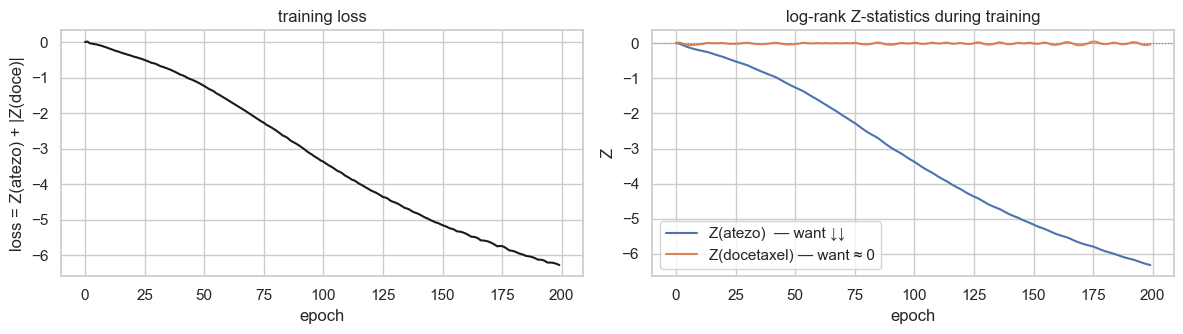

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(hist["epoch"], hist["loss"], color="k")
axes[0].set_title("training loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss = Z(atezo) + |Z(doce)|")
axes[1].plot(hist["epoch"], hist["z_treatment"], label="Z(atezo)  — want ↓↓", color="C0")
axes[1].plot(hist["epoch"], hist["z_control"],   label="Z(docetaxel) — want ≈ 0", color="C1")
axes[1].axhline(0, color="gray", linestyle=":", linewidth=0.8)
axes[1].set_title("log-rank Z-statistics during training")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("Z")
axes[1].legend()
plt.tight_layout()

In [4]:
# Score both cohorts
with torch.no_grad():
    poplar_score = model.score(torch.tensor(Xp)).numpy()
    oak_score    = model.score(torch.tensor(Xo)).numpy()

poplar_out = poplar.assign(pbmf_score=poplar_score, pbmf_bplus=(poplar_score >= 0.5).astype(int))
oak_out    = oak.assign(   pbmf_score=oak_score,    pbmf_bplus=(oak_score    >= 0.5).astype(int))

rows = [
    ("POPLAR (train)", evaluate_biomarker(poplar_out, label_col="pbmf_bplus").as_series()),
    ("OAK (held-out)", evaluate_biomarker(oak_out,    label_col="pbmf_bplus").as_series()),
]
pd.DataFrame({k: v for k, v in rows})

,POPLAR (train),OAK (held-out)
n_B+,114,371
n_B-,97,270
HR(Tx|B+),0.28,0.636
CI(Tx|B+),"[0.17, 0.47]","[0.50, 0.82]"
p(Tx|B+),9.37e-07,0.000374
HR(Tx|B-),1.69,0.724
CI(Tx|B-),"[1.10, 2.60]","[0.55, 0.95]"
p(Tx|B-),0.017,0.0206
HR+/HR-,0.166,0.878
p(interaction),1.26e-07,0.544


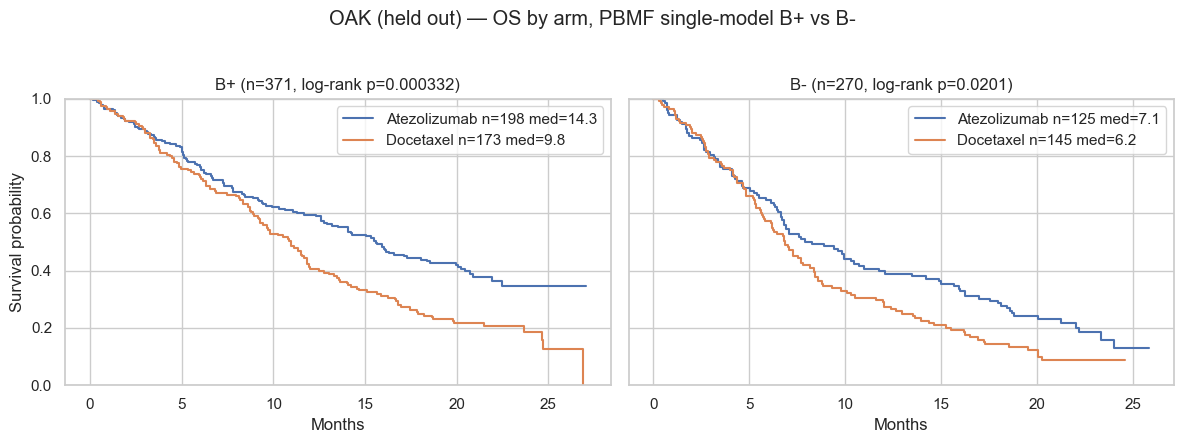

In [5]:
plot_km_strata(oak_out, label_col="pbmf_bplus",
               title="OAK (held out) — OS by arm, PBMF single-model B+ vs B-")
plt.show()

## Score distribution + mechanism sanity check

Does the model mostly just re-learn bTMB, or is it using the other features?

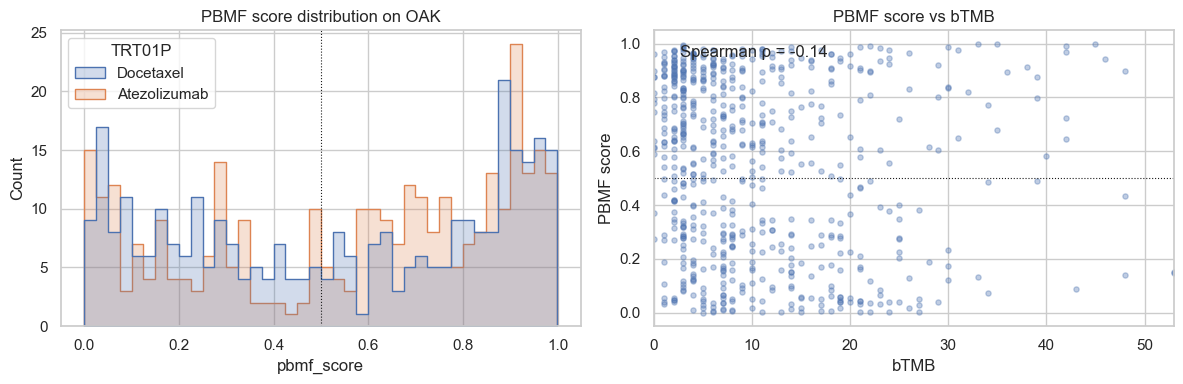

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(oak_out, x="pbmf_score", hue="TRT01P", bins=40, ax=axes[0], element="step")
axes[0].axvline(0.5, color="k", linestyle=":", linewidth=0.8)
axes[0].set_title("PBMF score distribution on OAK")

axes[1].scatter(oak_out["btmb"], oak_out["pbmf_score"], alpha=0.35, s=14)
axes[1].set_xlabel("bTMB"); axes[1].set_ylabel("PBMF score")
axes[1].set_xlim(0, oak_out["btmb"].quantile(0.99))
axes[1].axhline(0.5, color="k", linestyle=":", linewidth=0.8)
axes[1].set_title("PBMF score vs bTMB")
from scipy.stats import spearmanr
rho, _ = spearmanr(oak_out["btmb"], oak_out["pbmf_score"])
axes[1].text(0.05, 0.95, f"Spearman ρ = {rho:.2f}", transform=axes[1].transAxes, va="top")
plt.tight_layout()

## Overfitting diagnostic — train on everything, evaluate on everything

A single model fit on the full 852-patient cohort and evaluated on the same data looks incredibly strong (HR+/HR- ≈ 0.13). Held-out performance is a fraction of that. This is exactly why the paper trains an **ensemble** with bagging (80% patient resample + random feature subset per model) — the averaged score is lower-variance and generalizes.

In [7]:
scaler_full = StandardScaler().fit(feat[clinical_cols])
Xf = np.hstack([scaler_full.transform(feat[clinical_cols]), feat[mut_cols].values]).astype(np.float32)
torch.manual_seed(0); np.random.seed(0)
m, _ = train_pbmf(
    torch.tensor(Xf),
    torch.tensor(feat["OS"].values, dtype=torch.float32),
    torch.tensor(feat["OS_event"].values, dtype=torch.float32),
    torch.tensor((feat["TRT01P"] == "Atezolizumab").astype(int).values, dtype=torch.long),
    hidden=64, lr=1e-3, weight_decay=1e-4, epochs=500, lam_control=1.0, seed=0,
)
with torch.no_grad():
    s = m.score(torch.tensor(Xf)).numpy()
feat_overfit = feat.assign(bplus=(s >= 0.5).astype(int))
print("Same-set fit (overfit):")
print(evaluate_biomarker(feat_overfit, label_col="bplus").as_series().to_string())

Same-set fit (overfit):
n_B+                       565
n_B-                       287
HR(Tx|B+)                0.334
CI(Tx|B+)         [0.27, 0.41]
p(Tx|B+)              1.38e-23
HR(Tx|B-)                 2.41
CI(Tx|B-)         [1.85, 3.14]
p(Tx|B-)              6.67e-11
HR+/HR-                  0.139
p(interaction)        1.89e-31


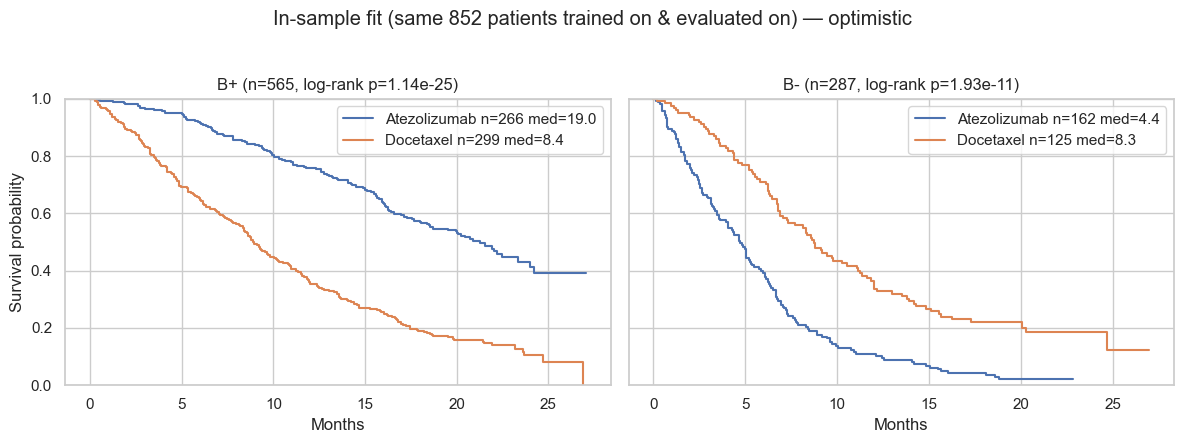

In [8]:
plot_km_strata(feat_overfit, label_col="bplus",
               title="In-sample fit (same 852 patients trained on & evaluated on) — optimistic")
plt.show()